1) Importing frameworks / libraries / modules

In [11]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

2) Setting dataset path (DATA_DIR) and selecting the device (GPU if available) for training

In [12]:
DATA_DIR = Path("../data/EuroSAT_RGB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


3) Defining image transformations

    - 'train_transform' for the training set (augmentation is used)
    - 'eval_transform' for the validation and test sets

    All images are resized to '64 x 64' pixels, converted into tensors and normalized using mean and standard deviation values

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

4) Loading and splitting the dataset

    Loading the full dataset from the path. There are 10 folders, each represents one class. The folder names are used as class labels.

    After loading the full dataset, it is split into 3 parts using 70/20/10:
    
    - 70% for training
    - 20% validation
    - 10% testing

    A fixed random seed is used, so same images will be assigned to the same sets each run

In [14]:
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)
classes = full_dataset.classes
n = len(full_dataset)
print(f"Classes: {classes}")
print(f"Total images: {n}")

# 70 / 20 / 10  split 
train_frac, val_frac, test_frac = 0.70, 0.20, 0.10
train_size = int(train_frac * n)
val_size   = int(val_frac   * n)
test_size  = n - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Split → train: {train_size} | val: {val_size} | test: {test_size}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Split → train: 18900 | val: 5400 | test: 2700


5) Applying training transformations to the training subset
        During split, 'eval_transform' was used for all splits, now for 'train_dataset' we apply 'train_transform'

In [15]:
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(img).convert("RGB")
        return self.transform(img), label

train_dataset = TransformSubset(train_dataset, train_transform)

6) Creating DataLoaders to  load images in small batch (fixed size 'batch_size') instead of loading the entire dataset
    
    Setting 'shuffle=True' for training dataset helps mixing images before each epoch, it prevents model from depending on the order

In [16]:
batch_size=32

train_loader = DataLoader(train_dataset, batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size, shuffle=False, num_workers=2, pin_memory=True)


7) Defining the CNN architecture (Inspired from VGG architecture - 3 blocks)

    - 'features' for extracting visual patterns, each block applies convolution, batch normalization, ReLU activation, and max pooling
    - 'classifier' for final class prediction, produces 10 output scores, one for each EuroSAT class


In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),   
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),  
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

8) Initializing the model, loss function, optimizer, setting epochs and learning rate scheduler

In [18]:
model     = SimpleCNN(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs    = 50
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

9) Training and validating the CNN model
    
    First running the model in training mode, then valuation with no gradient calculation. Loss and accuracy is calculated and stored. If there is progress in accuracy, then saving the weights. If no progress for 'patience' number of epochs, then early stoppage. 

In [19]:
train_losses, train_accs, val_losses, val_accs = [], [], [], []

best_val_acc  = 0.0
patience      = 8          # for early stoppage
patience_ctr  = 0

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        correct       += (predicted == labels).sum().item()
        total         += labels.size(0)

    scheduler.step()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc  = correct / total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct  += (predicted == labels).sum().item()
            val_total    += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc  = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"train loss: {epoch_train_loss:.4f}  acc: {epoch_train_acc:.4f}  |  "
          f"val loss: {epoch_val_loss:.4f}  acc: {epoch_val_acc:.4f}  |  "
          f"lr: {current_lr:.6f}")

    # Saving the weights if there is progress
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "../outputs/eurosat_cnn_best.pth")
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} "
                  f"(no val improvement for {patience} epochs)")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch [01/50]  train loss: 1.2027  acc: 0.5809  |  val loss: 0.9174  acc: 0.6341  |  lr: 0.000999
Epoch [02/50]  train loss: 0.8607  acc: 0.6930  |  val loss: 1.0147  acc: 0.6743  |  lr: 0.000996
Epoch [03/50]  train loss: 0.7668  acc: 0.7241  |  val loss: 0.5234  acc: 0.8207  |  lr: 0.000991
Epoch [04/50]  train loss: 0.7003  acc: 0.7541  |  val loss: 0.6529  acc: 0.7787  |  lr: 0.000984
Epoch [05/50]  train loss: 0.6682  acc: 0.7670  |  val loss: 0.8487  acc: 0.7231  |  lr: 0.000976
Epoch [06/50]  train loss: 0.5992  acc: 0.7925  |  val loss: 0.4720  acc: 0.8343  |  lr: 0.000965
Epoch [07/50]  train loss: 0.5785  acc: 0.8006  |  val loss: 0.5413  acc: 0.8161  |  lr: 0.000953
Epoch [08/50]  train loss: 0.5185  acc: 0.8226  |  val loss: 0.3608  acc: 0.8750  |  lr: 0.000939
Epoch [09/50]  train loss: 0.4814  acc: 0.8410  |  val loss: 0.3376  acc: 0.8848  |  lr: 0.000923
Epoch [10/50]  train loss: 0.4378  acc: 0.8522  |  val loss: 0.3045  acc: 0.8941  |  lr: 0.000905
Epoch [11/50]  train

10) Plotting the learning curves. Two plots are created: 
    - Accuracy curve
    - Loss curve

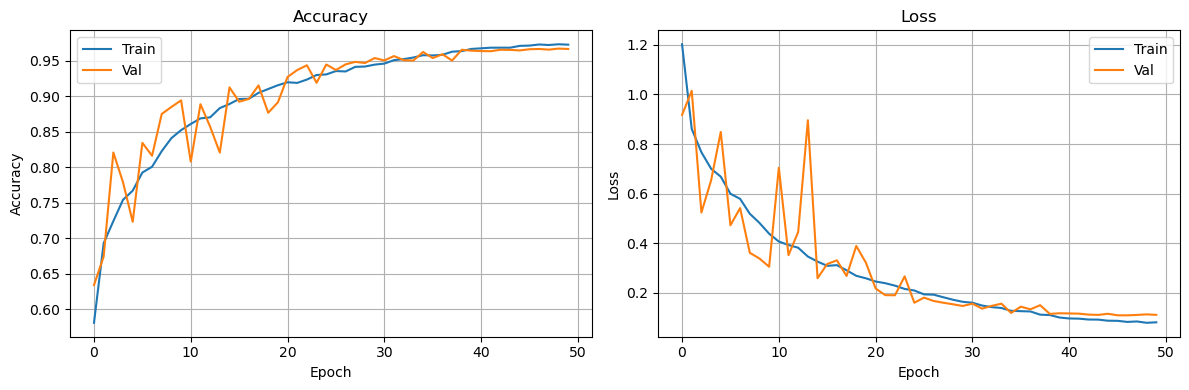

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_accs, label="Train")
axes[0].plot(val_accs,   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_losses, label="Train")
axes[1].plot(val_losses,   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Loss"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("../outputs/cnn_learning_curves.png", dpi=300)
plt.show()

11) Evaluating the best model on the test set


Test set results:
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.96      0.96       300
              Forest       0.97      0.99      0.98       297
HerbaceousVegetation       0.95      0.95      0.95       302
             Highway       0.95      0.99      0.97       269
          Industrial       0.98      0.98      0.98       257
             Pasture       0.94      0.97      0.96       187
       PermanentCrop       0.96      0.94      0.95       254
         Residential       0.99      0.99      0.99       314
               River       0.98      0.92      0.95       245
             SeaLake       0.99      0.99      0.99       275

            accuracy                           0.97      2700
           macro avg       0.97      0.97      0.97      2700
        weighted avg       0.97      0.97      0.97      2700



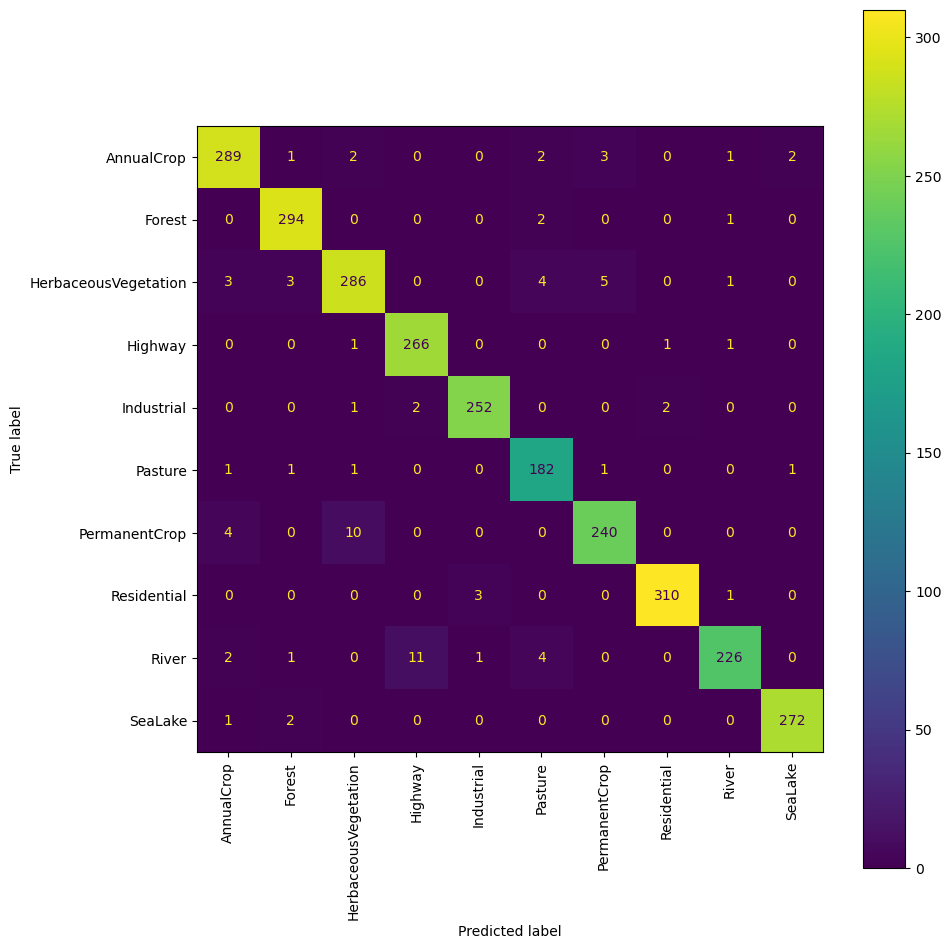

In [21]:
model.load_state_dict(torch.load("../outputs/eurosat_cnn_best.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nTest set results:")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    xticks_rotation=90, ax=ax)
plt.tight_layout()
plt.savefig("../outputs/cnn_confusion_matrix.png", dpi=300)
plt.show()

12) Creating a prediction function for new images

In [23]:
def predict(image_path: str):
    """Predict land-cover class for a single image file."""
    img    = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    return classes[pred_idx.item()], conf.item()

13) Showing predictions on 10 random images

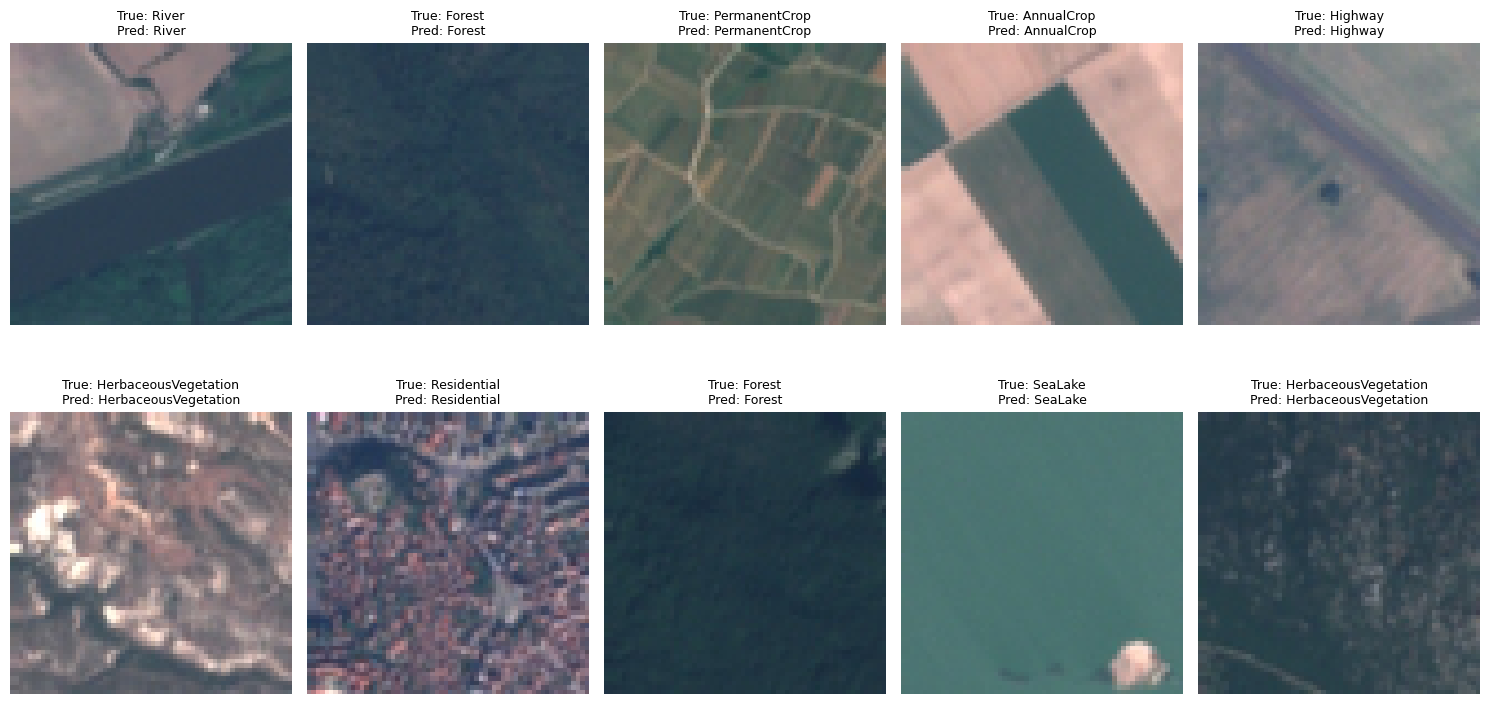

In [27]:
import random

model.eval()

class_names = full_dataset.classes  

random_indices = random.sample(range(len(full_dataset)), 10)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(random_indices):
    image_path, true_label = full_dataset.samples[idx]

    img = Image.open(image_path).convert("RGB")

    input_tensor = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)

    predicted_label = predicted.item()

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}",
        fontsize=9
    )

plt.tight_layout()
plt.show()